## Regime-Aware Sector Rotation Model

This notebook builds a regime-aware sector rotation model using 25 years of S&P 500 data to answer a practical question: **which sectors should you rotate into given current market conditions?**

The core hypothesis is that sector performance is not random — it depends on the broader market environment. By classifying the market into distinct regimes and measuring historical sector returns within each, we can make informed, data-driven rotation decisions.

### What it does

1. **Data preparation** — loads S&P 500 stock price history alongside company metadata (sector, industry, exchange). Stocks are merged with their sector labels and sorted chronologically per symbol.

2. **Feature engineering** — computes a rich set of per-stock technical indicators:
   - Multi-horizon returns: 1-day, 5-day, 21-day, 63-day
   - Simple moving averages: SMA 10, 21, 50, 200
   - Price-to-SMA ratios (50-day and 200-day)
   - Momentum: 21-day and 63-day
   - Volatility: rolling 21-day and 63-day standard deviation of daily returns
   - Volume ratio: current volume vs. 21-day average
   - Forward returns: 5-day, 21-day, and 63-day (used as prediction targets)

3. **Market regime classification** — aggregates stock-level data into a daily market table, then labels each day with two independent regimes:
   - **Trend regime** (bull / sideways / bear): based on the 63-day average market return — above +8% is bull, below -8% is bear, otherwise sideways
   - **Volatility regime** (low / normal / high): based on 21-day average volatility relative to its historical 25th and 75th percentiles
   - These combine into **9 possible regimes** (e.g., , )

4. **Sector performance analysis** — for each of the 9 regimes, computes per-sector statistics across all historical observations: average and median 21-day and 63-day forward returns, hit rate (% of positive outcomes), standard deviation, and a Sharpe-like return-to-risk ratio.

5. **Current recommendation** — detects the most recent market regime and surfaces the top 3 historically strongest sectors for that regime, with expected 21-day return and hit rate.

### Data
Two CSV files: `sp500_stocks.csv` (daily OHLCV price data) and `sp500_companies.csv` (company metadata including sector and date added to the index).

### Stack
Python 3 · pandas · numpy · matplotlib · seaborn

## 1. Setup

In [240]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns # data visualization
import matplotlib.pyplot as plt # plotting
import yfinance as yf # to fetch financial data

## 2. Data Loading

In [241]:
# Load CSV files

stocks = pd.read_csv('data/raw/sp500_stocks.csv')
companies = pd.read_csv('data/raw/sp500_companies.csv')

print(stocks.head())
print(companies.head())

         date       open       high        low      close     volume symbol
0  2000-01-03  47.071068  47.183143  40.271914  43.036407  4674353.0      A
1  2000-01-04  40.720196  41.168494  38.702866  39.748890  4765083.0      A
2  2000-01-05  39.599454  39.748888  36.050450  37.283260  5758642.0      A
3  2000-01-06  36.834972  37.059121  34.742923  35.863663  2534434.0      A
4  2000-01-07  35.303308  39.412688  35.265952  38.852318  2819626.0      A
  symbol              company                  sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                     sub_industry             headquarters  date_added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisc

In [242]:
# Inspect data
print(stocks.info())
print(companies.info())

# Fix data types
stocks['date'] = pd.to_datetime(stocks['date'])
companies['date_added'] = pd.to_datetime(companies['date_added'], errors='coerce')

print(stocks['date'].dtype)
print(companies['date_added'].dtype)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2909982 entries, 0 to 2909981
Data columns (total 7 columns):
 #   Column  Dtype  
---  ------  -----  
 0   date    object 
 1   open    float64
 2   high    float64
 3   low     float64
 4   close   float64
 5   volume  float64
 6   symbol  object 
dtypes: float64(5), object(2)
memory usage: 155.4+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 503 entries, 0 to 502
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   symbol        503 non-null    object
 1   company       503 non-null    object
 2   sector        503 non-null    object
 3   sub_industry  503 non-null    object
 4   headquarters  503 non-null    object
 5   date_added    503 non-null    object
 6   founded       503 non-null    object
dtypes: object(7)
memory usage: 27.6+ KB
None
datetime64[ns]
datetime64[ns]


In [243]:
# Merge stock data with company info and sort
merged = stocks.merge(companies, on='symbol', how='left')
merged = merged.sort_values(['symbol', 'date']).reset_index(drop=True)
merged[['date', 'symbol', 'close', 'sector']].head(10)

,date,symbol,close,sector
0,2000-01-03,A,43.036407,Health Care
1,2000-01-04,A,39.748890,Health Care
2,2000-01-05,A,37.283260,Health Care
3,2000-01-06,A,35.863663,Health Care
4,2000-01-07,A,38.852318,Health Care
5,2000-01-10,A,41.205853,Health Care
6,2000-01-11,A,40.645504,Health Care
7,2000-01-12,A,39.823608,Health Care
8,2000-01-13,A,40.421341,Health Care
9,2000-01-14,A,40.869637,Health Care


## 3. Feature Engineering

In [244]:
# Calculate 1-day returns
merged['ret_1d'] = merged.groupby('symbol')['close'].pct_change(1)

# Calculate 5-day returns
merged['ret_5d'] = merged.groupby('symbol')['close'].pct_change(5)

# Calculate 21-day returns
merged['ret_21d'] = merged.groupby('symbol')['close'].pct_change(21)

# Calculate 63-day returns
merged['ret_63d'] = merged.groupby('symbol')['close'].pct_change(63)


merged[["date", "symbol", "close", "ret_1d", "ret_21d"]].head(15)

,date,symbol,close,ret_1d,ret_21d
0,2000-01-03,A,43.036407,NaN,NaN
1,2000-01-04,A,39.748890,-0.076389,NaN
2,2000-01-05,A,37.283260,-0.062030,NaN
3,2000-01-06,A,35.863663,-0.038076,NaN
4,2000-01-07,A,38.852318,0.083334,NaN
5,2000-01-10,A,41.205853,0.060576,NaN
6,2000-01-11,A,40.645504,-0.013599,NaN
7,2000-01-12,A,39.823608,-0.020221,NaN
8,2000-01-13,A,40.421341,0.015010,NaN
9,2000-01-14,A,40.869637,0.011091,NaN


In [245]:
# Calculate moving averages
merged["sma_10"]  = merged.groupby("symbol")["close"].transform(lambda x: x.rolling(10).mean())
merged["sma_21"]  = merged.groupby("symbol")["close"].transform(lambda x: x.rolling(21).mean())
merged["sma_50"]  = merged.groupby("symbol")["close"].transform(lambda x: x.rolling(50).mean())
merged["sma_200"] = merged.groupby("symbol")["close"].transform(lambda x: x.rolling(200).mean())

# Calculate price relative to moving average
merged["price_to_sma_50"]  = merged["close"] / merged["sma_50"]
merged["price_to_sma_200"] = merged["close"] / merged["sma_200"]

In [246]:
# Calculate momentum
merged["momentum_21d"] = merged.groupby("symbol")["close"].transform(lambda x: x / x.shift(21) - 1)
merged["momentum_63d"] = merged.groupby("symbol")["close"].transform(lambda x: x / x.shift(63) - 1)

# Calculate volatility
merged["volatility_21d"] = merged.groupby("symbol")["ret_1d"].transform(lambda x: x.rolling(21).std())
merged["volatility_63d"] = merged.groupby("symbol")["ret_1d"].transform(lambda x: x.rolling(63).std())

# Calculate rolling average volume and volume ratio
merged["avg_volume_21d"]   = merged.groupby("symbol")["volume"].transform(lambda x: x.rolling(21).mean())
merged["volume_ratio_21d"] = merged["volume"] / merged["avg_volume_21d"]

In [247]:
# Calculate forward returns

merged["fwd_ret_5d"] = merged.groupby("symbol")["close"].transform(lambda x: x.shift(-5) / x - 1)
merged["fwd_ret_21d"] = merged.groupby("symbol")["close"].transform(lambda x: x.shift(-21) / x - 1)
merged["fwd_ret_63d"] = merged.groupby("symbol")["close"].transform(lambda x: x.shift(-63) / x - 1)

merged.head()

,date,open,high,low,close,volume,symbol,company,sector,sub_industry,...,price_to_sma_200,momentum_21d,momentum_63d,volatility_21d,volatility_63d,avg_volume_21d,volume_ratio_21d,fwd_ret_5d,fwd_ret_21d,fwd_ret_63d
0,2000-01-03,47.071068,47.183143,40.271914,43.036407,4674353.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.042535,0.062500,0.361111
1,2000-01-04,40.720196,41.168494,38.702866,39.748890,4765083.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.022557,0.169173,0.406015
2,2000-01-05,39.599454,39.748888,36.050450,37.283260,5758642.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.068136,0.222445,0.554108
3,2000-01-06,36.834972,37.059121,34.742923,35.863663,2534434.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.127083,0.325000,0.750000
4,2000-01-07,35.303308,39.412688,35.265952,38.852318,2819626.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.051923,0.215384,0.876923


In [248]:
# Inspect missing values

merged[[
    "ret_1d", "ret_21d", "sma_50", "sma_200",
    "momentum_21d", "volatility_21d", "fwd_ret_21d"
]].isna().sum()

ret_1d               503
ret_21d            10563
sma_50             24647
sma_200           100003
momentum_21d       10563
volatility_21d     10563
fwd_ret_21d        10563
dtype: int64

## 4. Market-Level Aggregation

In [249]:
# Build market-level table
market = (
    merged.groupby("date")
      .agg(
          market_ret_1d=        ("ret_1d",         "mean"),
          market_ret_5d=        ("ret_5d",         "mean"),
          market_ret_21d=       ("ret_21d",        "mean"),
          market_ret_63d=       ("ret_63d",        "mean"),
          market_volatility_21d=("volatility_21d", "mean"),
          market_volatility_63d=("volatility_63d", "mean"),
          breadth_pct_positive_1d=("ret_1d", lambda x: (x > 0).mean()),
          avg_volume_ratio=     ("volume_ratio_21d", "mean")
      )
      .reset_index()
)

# Add breadth above moving averages
breadth = (
    merged.assign(
        above_sma50=merged["close"]  > merged["sma_50"],
        above_sma200=merged["close"] > merged["sma_200"]
    )
    .groupby("date")
    .agg(
        breadth_pct_above_sma50= ("above_sma50",  "mean"),
        breadth_pct_above_sma200=("above_sma200", "mean")
    )
    .reset_index()
)

market = market.merge(breadth, on="date", how="left")
market.head()

,date,market_ret_1d,market_ret_5d,market_ret_21d,market_ret_63d,market_volatility_21d,market_volatility_63d,breadth_pct_positive_1d,avg_volume_ratio,breadth_pct_above_sma50,breadth_pct_above_sma200
0,2000-01-03,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.0,0.0
1,2000-01-04,-0.025896,NaN,NaN,NaN,NaN,NaN,0.131805,NaN,0.0,0.0
2,2000-01-05,0.008296,NaN,NaN,NaN,NaN,NaN,0.578797,NaN,0.0,0.0
3,2000-01-06,0.004777,NaN,NaN,NaN,NaN,NaN,0.567335,NaN,0.0,0.0
4,2000-01-07,0.027303,NaN,NaN,NaN,NaN,NaN,0.770774,NaN,0.0,0.0


## 5. Regime Classification

In [250]:
# Define and apply trend regime (Bull / Sideways / Bear)
def classify_trend(ret_63d):
    '''
    Labels the market based on 63-day return:
    above +8%  → bull
    below -8%  → bear
    otherwise  → sideways
    '''
    if pd.isna(ret_63d):
        return np.nan
    elif ret_63d > 0.08:
        return "bull"
    elif ret_63d < -0.08:
        return "bear"
    else:
        return "sideways"

market["trend_regime"] = market["market_ret_63d"].apply(classify_trend)

# Define and apply volatility regime (low / normal / high)
vol_25 = market["market_volatility_21d"].quantile(0.25)
vol_75 = market["market_volatility_21d"].quantile(0.75)

def classify_vol(vol):
    '''
    above 75th percentile → high_vol
    below 25th percentile → low_vol
    otherwise             → normal_vol
    '''
    if pd.isna(vol):
        return np.nan
    elif vol > vol_75:
        return "high_vol"
    elif vol < vol_25:
        return "low_vol"
    else:
        return "normal_vol"

market["vol_regime"] = market["market_volatility_21d"].apply(classify_vol)

# Create combined regime
market["combined_regime"] = market["trend_regime"] + "_" + market["vol_regime"]
market[63:69]

,date,market_ret_1d,market_ret_5d,market_ret_21d,market_ret_63d,market_volatility_21d,market_volatility_63d,breadth_pct_positive_1d,avg_volume_ratio,breadth_pct_above_sma50,breadth_pct_above_sma200,trend_regime,vol_regime,combined_regime
63,2000-04-03,-0.006412,0.007213,0.077762,0.072094,0.041995,0.037596,0.495726,0.946312,0.726496,0.0,sideways,high_vol,sideways_high_vol
64,2000-04-04,-0.004664,0.008254,0.083950,0.091969,0.041497,0.037635,0.424501,1.253016,0.729345,0.0,bull,high_vol,bull_high_vol
65,2000-04-05,0.007103,0.013794,0.113153,0.093426,0.040561,0.037639,0.508523,0.995129,0.741477,0.0,bull,high_vol,bull_high_vol
66,2000-04-06,0.013092,0.021352,0.120243,0.106330,0.040593,0.037556,0.599432,0.838172,0.767045,0.0,bull,high_vol,bull_high_vol
67,2000-04-07,0.004081,0.010810,0.103605,0.083461,0.040629,0.037378,0.440341,0.782538,0.750000,0.0,bull,high_vol,bull_high_vol
68,2000-04-10,-0.009274,0.008518,0.099447,0.056127,0.040671,0.037375,0.460227,0.800207,0.735795,0.0,sideways,high_vol,sideways_high_vol


## 6. Regime Visualization

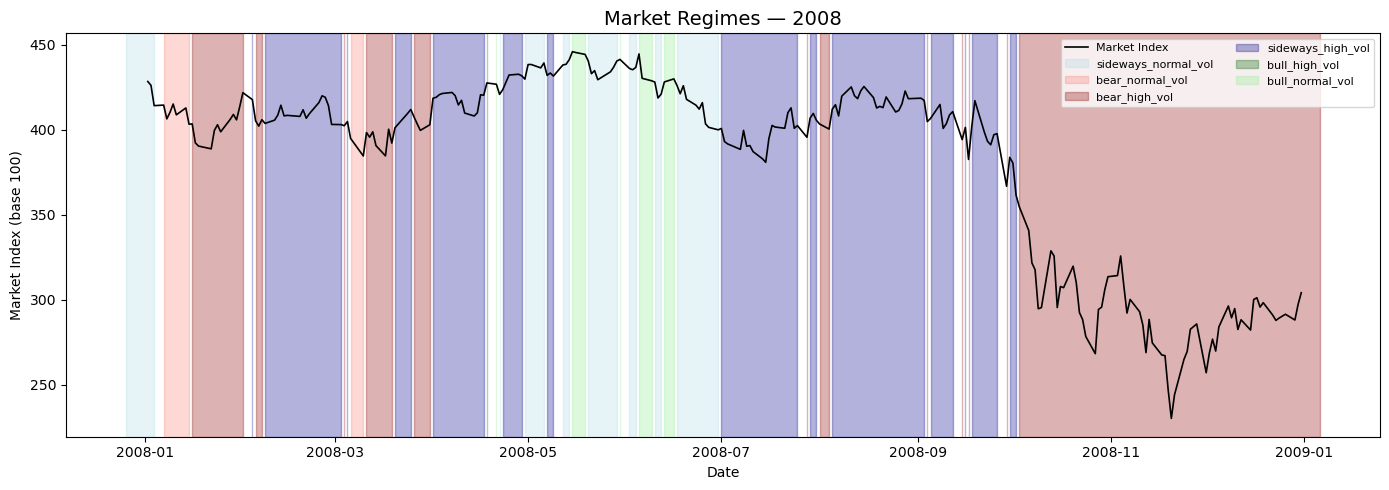

In [251]:
# Regime timeline chart
market["market_index"] = 100 * (1 + market["market_ret_1d"]).cumprod()

plot_df = market[["date", "market_index", "combined_regime"]].dropna().sort_values("date").reset_index(drop=True)

plot_df['changed']    = plot_df['combined_regime'].ne(plot_df['combined_regime'].shift())
plot_df['segment_id'] = plot_df['changed'].cumsum()
plot_df['start_date'] = plot_df.groupby('segment_id')['date'].transform('first')
plot_df['end_date']   = plot_df.groupby('segment_id')['date'].transform('last')

segments = plot_df.drop_duplicates('segment_id')[['segment_id', 'combined_regime', 'start_date', 'end_date']]

colors = {
    'bull_low_vol':       'green',
    'bull_normal_vol':    'lightgreen',
    'bull_high_vol':      'darkgreen',
    'bear_low_vol':       'red',
    'bear_normal_vol':    'salmon',
    'bear_high_vol':      'darkred',
    'sideways_low_vol':   'blue',
    'sideways_normal_vol':'lightblue',
    'sideways_high_vol':  'darkblue'
}

# Filter to 2008 for a focused view
zoom_start = pd.to_datetime('2008-01-01')
zoom_end   = pd.to_datetime('2008-12-31')
zoom_df    = plot_df[(plot_df['date'] >= zoom_start) & (plot_df['date'] <= zoom_end)]
zoom_segments = segments[
    (segments.start_date <= zoom_end) &
    (segments.end_date   >= zoom_start)
]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(zoom_df['date'], zoom_df['market_index'], color='black', linewidth=1.2, label='Market Index')

seen_regimes = set()
for _, segment in zoom_segments.iterrows():
    regime = segment['combined_regime']
    color  = colors.get(regime, 'gray')
    label  = regime if regime not in seen_regimes else None
    ax.axvspan(segment['start_date'], segment['end_date'], color=color, alpha=0.3, label=label)
    seen_regimes.add(regime)

ax.set_title('Market Regimes — 2008', fontsize=14)
ax.set_xlabel('Date')
ax.set_ylabel('Market Index (base 100)')
ax.legend(loc='upper right', fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## 7. Sector Performance by Regime

In [252]:
# Merge market table to stock_level data

df = merged.merge(
    market[["date", "trend_regime", "vol_regime", "combined_regime"]],
    on="date",
    how="left"
)

df[63:69]

,date,open,high,low,close,volume,symbol,company,sector,sub_industry,...,volatility_21d,volatility_63d,avg_volume_21d,volume_ratio_21d,fwd_ret_5d,fwd_ret_21d,fwd_ret_63d,trend_regime,vol_regime,combined_regime
63,2000-04-03,61.565979,61.715410,54.841539,58.577339,2030875.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.118649,0.079274,2.679454e+06,0.757944,0.093112,-0.066327,-0.248087,sideways,high_vol,sideways_high_vol
64,2000-04-04,58.577324,61.192384,49.013681,55.887547,3519884.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.049399,0.078845,2.575948e+06,1.366442,0.079546,-0.034760,-0.248663,bull,high_vol,bull_high_vol
65,2000-04-05,55.439238,59.698046,53.870200,57.942219,2109163.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.047211,0.078410,2.309203e+06,0.913373,-0.112830,-0.056737,-0.286912,bull,high_vol,bull_high_vol
66,2000-04-06,58.801459,62.761406,58.016940,62.761406,1375073.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.048456,0.078708,2.186399e+06,0.628921,-0.142857,-0.192857,-0.357142,bull,high_vol,bull_high_vol
67,2000-04-07,64.255748,74.715987,63.994246,72.922806,2975224.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.062070,0.080466,2.208334e+06,1.347271,-0.322234,-0.342726,-0.438525,bull,high_vol,bull_high_vol
68,2000-04-10,72.922818,72.922818,62.985588,64.031616,2956071.0,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,...,0.065474,0.081989,2.231035e+06,1.324977,-0.257877,-0.281214,-0.371646,sideways,high_vol,sideways_high_vol


In [253]:
# Calculate sector-relative performance

sector_perf = (
    df.groupby(["combined_regime", "sector"])
      .agg(
          avg_fwd_ret_21d=("fwd_ret_21d", "mean"),
          median_fwd_ret_21d=("fwd_ret_21d", "median"),
          avg_fwd_ret_63d=("fwd_ret_63d", "mean"),
          obs=("symbol", "count"),
          hit_rate = (("fwd_ret_21d", lambda x: (x > 0).mean())),
          std_fwd_ret_21d=("fwd_ret_21d", "std")
      )
      .reset_index()
      .sort_values(["combined_regime", "avg_fwd_ret_21d"], ascending=[True, False])
)

# Calculate a Sharpe-like ratio for each sector and regime
sector_perf['sharpe_like'] = sector_perf['avg_fwd_ret_21d'] / sector_perf['std_fwd_ret_21d']

# View top sectors for a regime
sector_perf[sector_perf["combined_regime"] == "bull_low_vol"].head(20)

,combined_regime,sector,avg_fwd_ret_21d,median_fwd_ret_21d,avg_fwd_ret_63d,obs,hit_rate,std_fwd_ret_21d,sharpe_like
33,bull_low_vol,Communication Services,0.015616,0.011064,0.032765,10447,0.568871,0.086335,0.180876
37,bull_low_vol,Financials,0.010824,0.012157,0.013103,39151,0.585298,0.061824,0.175073
35,bull_low_vol,Consumer Staples,0.010229,0.009985,0.023980,18652,0.579991,0.057017,0.179408
34,bull_low_vol,Consumer Discretionary,0.010126,0.009403,0.017895,24425,0.555005,0.082816,0.122273
39,bull_low_vol,Industrials,0.009966,0.009351,0.020689,39225,0.559873,0.069509,0.143384
38,bull_low_vol,Health Care,0.009792,0.008300,0.031269,30933,0.553357,0.074229,0.131910
40,bull_low_vol,Information Technology,0.008788,0.008415,0.023198,34250,0.544876,0.092282,0.095233
43,bull_low_vol,Utilities,0.008740,0.009415,0.023055,16592,0.586789,0.050879,0.171771
42,bull_low_vol,Real Estate,0.005809,0.007342,0.009474,16780,0.549702,0.059087,0.098316
41,bull_low_vol,Materials,0.005495,0.005954,0.013077,13276,0.537361,0.072937,0.075335


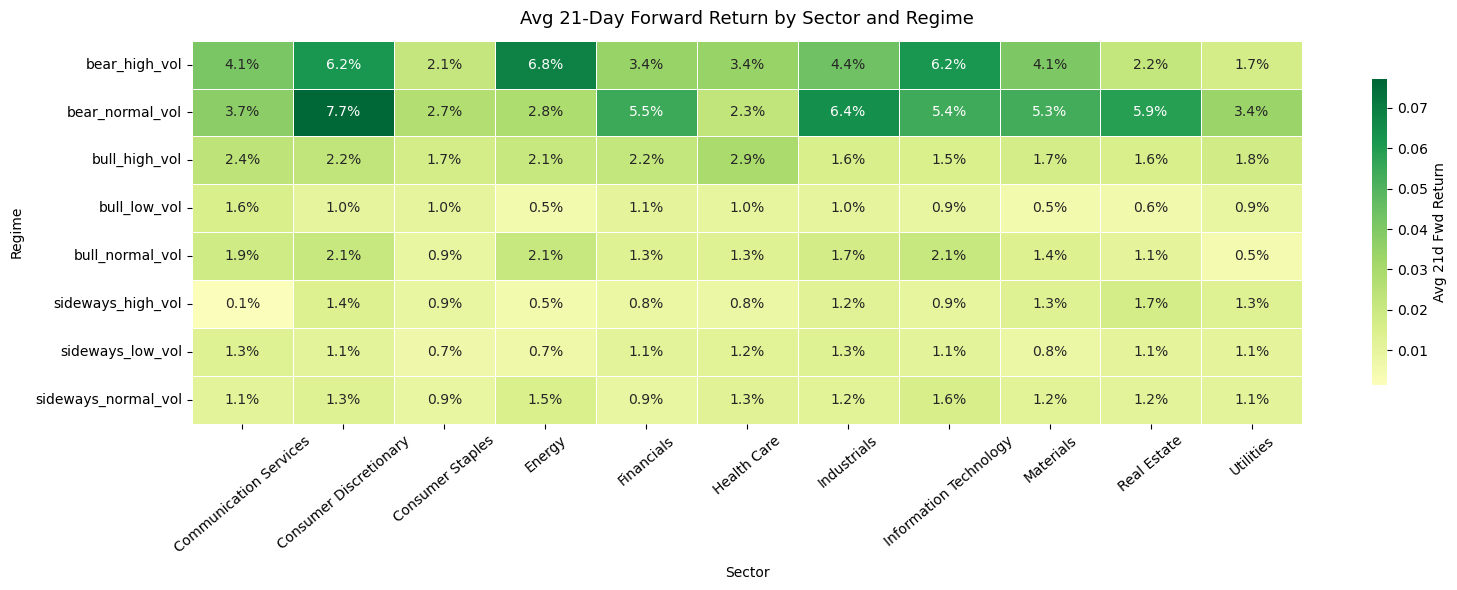

In [254]:
# Visualize average 21-day forward return by sector and regime
data = sector_perf.pivot(
    index="combined_regime",
    columns="sector",
    values="avg_fwd_ret_21d"
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    data=data,
    annot=True,
    fmt=".1%",
    cmap="RdYlGn",
    center=0,
    linewidths=0.4,
    ax=ax,
    cbar_kws={"label": "Avg 21d Fwd Return", "shrink": 0.8}
)
ax.set_title("Avg 21-Day Forward Return by Sector and Regime", fontsize=13, pad=12)
ax.set_xlabel("Sector", labelpad=8)
ax.set_ylabel("Regime", labelpad=8)
ax.tick_params(axis='x', rotation=40)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.show()

## 8. Current Regime Recommendation

In [255]:
# Get top sectors in each regime

def get_top_sectors_for_regime(regime, top_n=3):
    '''
    Given a regime like "bear_high_vol", it returns the best sectors historically.
    '''
    
    result = (
        sector_perf[sector_perf["combined_regime"] == regime]
        .sort_values("avg_fwd_ret_21d", ascending=False)
        .head(top_n)
    )
    return result[["sector", "avg_fwd_ret_21d", "avg_fwd_ret_63d", "obs", "hit_rate"]]

get_top_sectors_for_regime('sideways_normal_vol', 5)

,sector,avg_fwd_ret_21d,avg_fwd_ret_63d,obs,hit_rate
84,Information Technology,0.015933,0.054372,133392,0.569277
80,Energy,0.014607,0.057808,42111,0.574173
78,Consumer Discretionary,0.013112,0.048452,93201,0.565144
82,Health Care,0.012681,0.037683,118141,0.579122
85,Materials,0.012189,0.039952,51018,0.573366


In [256]:
# Get the current regime
latest_market  = market.dropna(subset=["combined_regime"]).sort_values("date").iloc[-1]
current_regime = latest_market["combined_regime"]

# Get top sectors for the current regime
top_sectors = get_top_sectors_for_regime(current_regime, top_n=3)

if not top_sectors.empty:
    print(f'Current regime: {current_regime}')
    print()
    print('Historically strongest sectors:')
    for _, row in top_sectors.iterrows():
        print(
            f"  - {row['sector']} "
            f"({row['avg_fwd_ret_21d']:+.2%} avg 21d return, "
            f"{row['hit_rate']:.2%} hit rate)"
        )

Current regime: sideways_normal_vol

Historically strongest sectors:
  - Information Technology (+1.59% avg 21d return, 56.93% hit rate)
  - Energy (+1.46% avg 21d return, 57.42% hit rate)
  - Consumer Discretionary (+1.31% avg 21d return, 56.51% hit rate)


## 9. Backtesting

Strategy: - Cumulative return: 46.6743 - Sharpe: 0.9856 - Max Drawdown: -0.5687
Benchmark: - Cumulative return: 35.8018 - Sharpe: 0.9861 - Max Drawdown: -0.5464


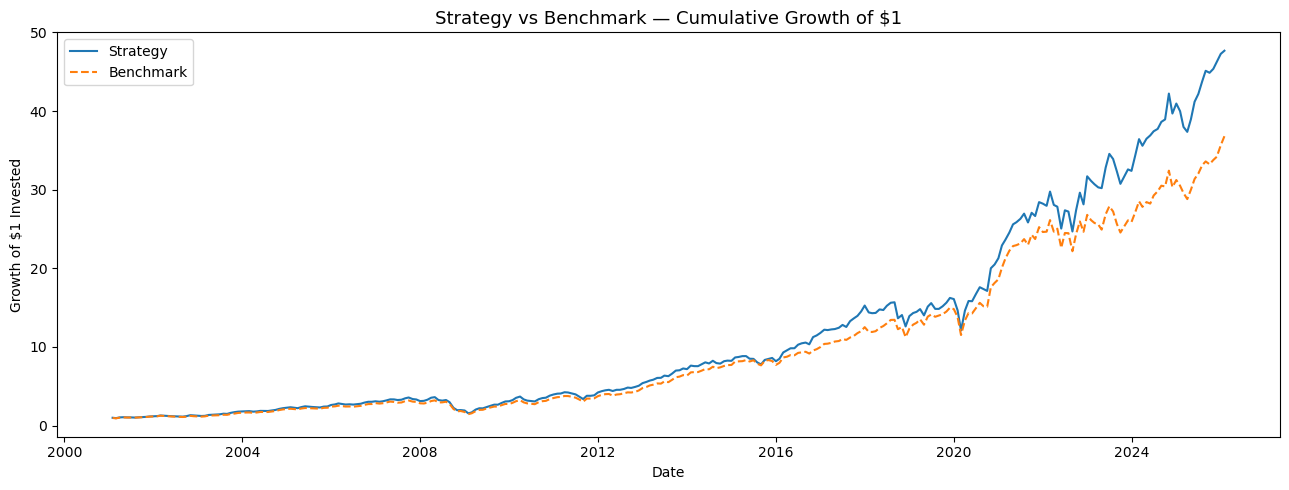

In [257]:

# Get trading days timeline
rebalance_dates_df = (
    df.groupby([df['date'].dt.year, df['date'].dt.month])['date']
      .max()
      .reset_index(drop=True)
      .to_frame(name='date')
)

# Get top sectors and fwd returns per date
sectors_filt = (
    df.merge(rebalance_dates_df, on='date', how='inner')
      .groupby(['date', 'sector'], as_index=False)
      .agg(fwd_ret_21d=('fwd_ret_21d', 'mean'))
      .sort_values('date')
)

sectors_filt = sectors_filt.merge(
    market[['date', 'combined_regime']],
    on='date',
    how='left'
)

def get_top_sectors_using_history(regime, top_n=3): # this function uses only historical data up to the current date

    top_sectors = (
        historical_sector_perf[(historical_sector_perf['combined_regime'] == regime) & (historical_sector_perf['obs'] >= 3)] # only consider sectors with at least 30 observations in that regime to ensure statistical significance
        .sort_values('avg_fwd_ret_21d', ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )
    return top_sectors


# Calculate strategy returns by applying the top sectors for each regime to the historical data and compare to benchmark (equal weight of all sectors)
results = []

for date in rebalance_dates_df['date']:

    history = sectors_filt[sectors_filt['date'] < date]

    if history['date'].nunique() < 12: # skip the first year since we don't have enough data to determine the top sectors for each regime
        continue

    regime = sectors_filt[sectors_filt['date'] == date]['combined_regime'].values[0]
    historical_sector_perf = history.groupby(['combined_regime', 'sector'], as_index=False).agg(avg_fwd_ret_21d=('fwd_ret_21d', 'mean'), obs = ('fwd_ret_21d', 'count'))
    top_3_sectors = get_top_sectors_using_history(regime, 5)[['sector', 'avg_fwd_ret_21d']]

    if top_3_sectors.empty:
        continue

    sectors_realized_ret = sectors_filt[(sectors_filt['sector'].isin(top_3_sectors['sector'])) & (sectors_filt['date'] == date)][['sector', 'fwd_ret_21d']].sort_values('sector')

    if sectors_realized_ret.empty:
        continue

    strategy_return = sectors_realized_ret['fwd_ret_21d'].mean() # equal weight return of the 3 sectors
    benchmark_return = sectors_filt[sectors_filt['date'] == date]['fwd_ret_21d'].mean() # average return across all sectors as benchmark

    results.append({
        'date': date,
        'regime': regime,
        'strategy_return': strategy_return,
        'benchmark_return': benchmark_return
    })

results_df = pd.DataFrame(results)

results_df = results_df.dropna(subset=['strategy_return', 'benchmark_return']).copy()
results_df = results_df.sort_values('date').reset_index(drop=True)

# Convert 21d forward returns into growth curves
results_df['strategy_growth'] = (1 + results_df['strategy_return']).cumprod()
results_df['benchmark_growth'] = (1 + results_df['benchmark_return']).cumprod()


# Add sharpe-like ratio of the strategy
mean_strategy_return = results_df['strategy_return'].mean()
std_strategy_return = results_df['strategy_return'].std()
strategy_sharpe = (mean_strategy_return / std_strategy_return) * np.sqrt(12)
# Add sharpe-like ratio of the benchmark
mean_benchmark_return = results_df['benchmark_return'].mean()
std_benchmark_return = results_df['benchmark_return'].std()
benchmark_sharpe = (mean_benchmark_return / std_benchmark_return) * np.sqrt(12)

# Max drawdown
peak = results_df['strategy_growth'].cummax()
drawdown_series = results_df['strategy_growth'] / peak - 1
max_drawdown_str = drawdown_series.min()
# Max drawdown benchmark
max_drawdown_benchk = (results_df['benchmark_growth'] / results_df['benchmark_growth'].cummax() - 1).min()

# Cumulative return strategy
cumm_return_str = results_df['strategy_growth'].iloc[-1] - 1
# Cumulative return benchmark
cumm_return_benchk = results_df['benchmark_growth'].iloc[-1] - 1



print(f"Strategy: - Cumulative return: {cumm_return_str:.4f} - Sharpe: {strategy_sharpe:.4f} - Max Drawdown: {max_drawdown_str:.4f}")
print(f"Benchmark: - Cumulative return: {cumm_return_benchk:.4f} - Sharpe: {benchmark_sharpe:.4f} - Max Drawdown: {max_drawdown_benchk:.4f}")

results_df.tail()
# Strategy vs benchmark growth chart
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(results_df['date'], results_df['strategy_growth'],  label='Strategy',  linewidth=1.5)
ax.plot(results_df['date'], results_df['benchmark_growth'], label='Benchmark', linewidth=1.5, linestyle='--')
ax.set_title('Strategy vs Benchmark — Cumulative Growth of $1', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1 Invested')
ax.legend()
plt.tight_layout()
plt.show()

## 10. VIX by Regime

In [258]:
from datetime import datetime

vix = yf.Ticker('^VIX').history(start=stocks['date'].min(), end= datetime.today()).reset_index('Date')
vix['Date'] = pd.to_datetime(vix['Date']).dt.tz_localize(None)
vix.rename(columns={'Close': 'vix', 'Date': 'date'}, inplace=True)

market_vix = market.merge(vix, left_on='date', right_on='date', how='left')[['date', 'combined_regime', 'vix']]
market_vix = market_vix.dropna(subset=['combined_regime']).copy() # drop rows where combined_regime is missing

market_vix['avg_vix'] = market_vix.groupby('combined_regime')['vix'].transform('mean').round(2)
market_vix.head()


,date,combined_regime,vix,avg_vix
63,2000-04-03,sideways_high_vol,24.030001,26.59
64,2000-04-04,bull_high_vol,27.120001,25.12
65,2000-04-05,bull_high_vol,28.410000,25.12
66,2000-04-06,bull_high_vol,27.150000,25.12
67,2000-04-07,bull_high_vol,24.389999,25.12


## Summary

This notebook built a regime-aware sector rotation model from 25 years of S&P 500 data.

| Step | Output |
|------|--------|
| Feature engineering | 15+ per-stock technical indicators |
| Market aggregation | Daily market-wide return, volatility, and breadth signals |
| Regime classification | 9 combined regimes (trend × volatility) |
| Sector analysis | Historical return, hit rate, and Sharpe-like ratio per regime |
| Recommendation | Top 3 sectors for the current regime |
| Backtest | Strategy vs equal-weight benchmark with Sharpe and max drawdown |